In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('figures', exist_ok=True)

In [15]:
# Performing EDA
df = pd.read_csv('/users/noreenibrar/downloads/creditcard.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
# Checking the Class Distribution in order to detemrien the number of normal cresit card transationcs vs fraud transactions
class_counts = df['Class'].value_counts()
print(class_counts)
# the dataset is higly imblaanced. Class 0(normal credit card transaction) shows that there have been 284,315 normal credit card transactioncs, while class 1 (fraud trasncations) shows there has been 492 fraud transactions.
# Calculate Fraud Rate
fraud_rate = round((class_counts[1] / len(df)) * 100, 3)
print("Fraud rate :", fraud_rate,'%')

(284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Class
0    284315
1       492


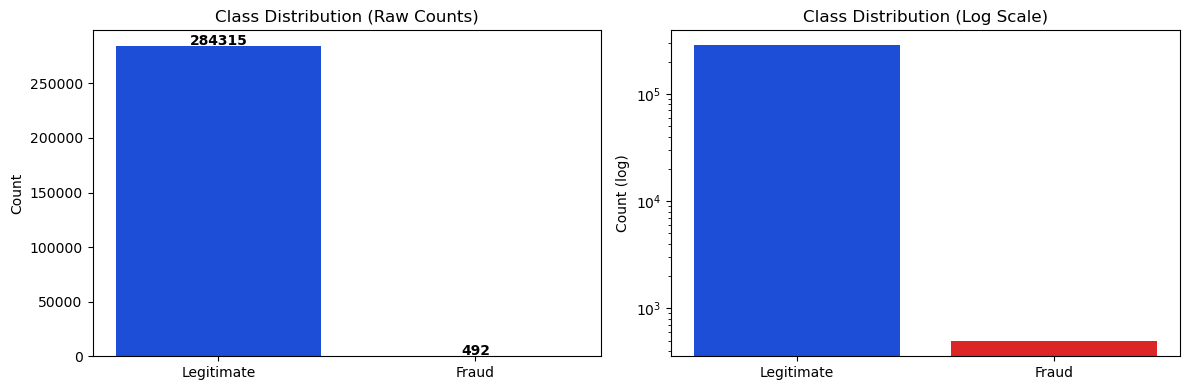

In [16]:
#Visualize
fig, axes = plt.subplots(1,2, figsize = (12,4))

#Raw counts
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values,
            color= ['#1d4ed8', '#dc2626'])
axes[0].set_title('Class Distribution (Raw Counts)')

axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values) :
    axes[0].text(i, v + 1000, str(v), ha='center', fontweight = 'bold')

#Log scale to see both bars
axes[1].bar(['Legitimate', 'Fraud'], class_counts.values,
            color= ['#1d4ed8', '#dc2626'], log=True)
axes[1].set_title('Class Distribution (Log Scale)')
axes[1].set_ylabel('Count (log)')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches= 'tight')


Legit transcations:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

fraudtransactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


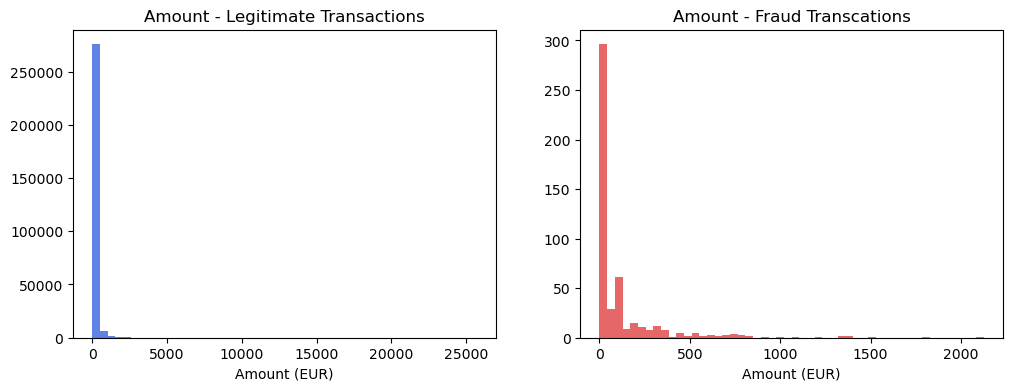

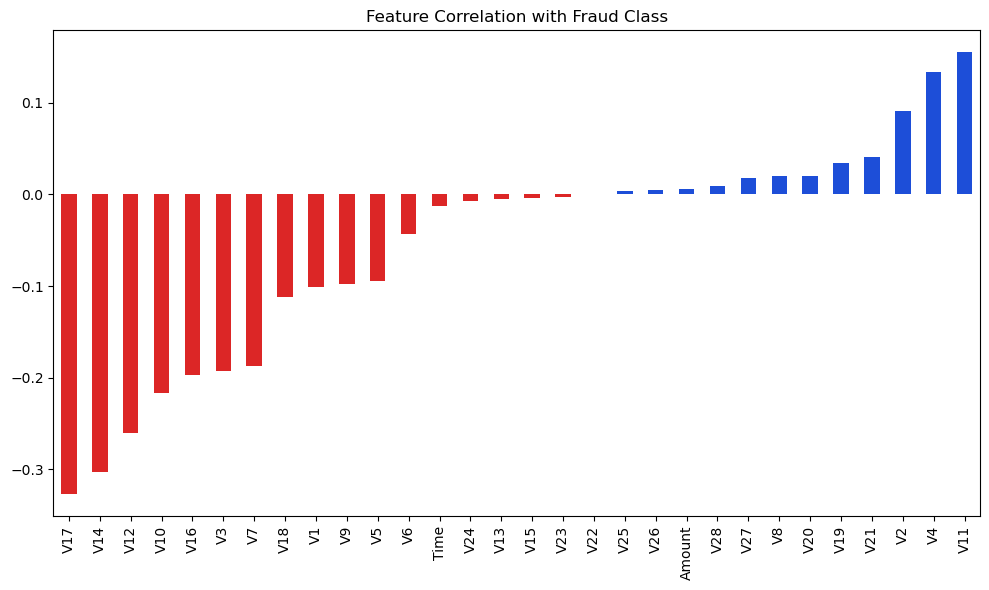

In [17]:
#Amount distribution by class
fig,axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(df[df['Class']==0]['Amount'],bins=50, color='#1d4ed8', alpha = 0.7)
axes[0].set_title('Amount - Legitimate Transactions')
axes[0].set_xlabel('Amount (EUR)')

axes[1].hist(df[df['Class']==1]['Amount'], bins=50, color='#dc2626', alpha =0.7)
axes[1].set_title('Amount - Fraud Transcations')
axes[1].set_xlabel('Amount (EUR)')

plt.savefig('amount_distribution.png', dpi = 150, bbox_inches ='tight')

#Statistical Comaprisaon
print('Legit transcations:')
print(df[df['Class']==0]['Amount'].describe())
print('\nfraudtransactions:')
print(df[df['Class']==1]['Amount'].describe())
#Fraud transactions tend to be smaller = fraudsters test cards with small amounts first

#Corrleation heatmap of V features with Class
correlations = df.corr()['Class'].drop('Class').sort_values()
plt.figure(figsize=(10, 6))
correlations.plot(kind='bar', color=['#dc2626' if x < 0 else '#1d4ed8' for x in correlations])
plt.title('Feature Correlation with Fraud Class')
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150, bbox_inches='tight')
#V17, V14, V12, V10 strongly negative - high = less likely fraud
#V11, V4, V2 positive - high = more likely fraud

In [18]:
#============================
#STEP 4: IMPORTING MACHINE LEARNING TOOLS
#============================
from sklearn.dummy import DummyClassifier
#Import the tool to calculate accuracy percentage and the detailed report tool to see precision and recall
from sklearn.metrics import accuracy_score, classification_report
#Import the tool to split the data into training and testing sets
from sklearn.model_selection import train_test_split

# Separate the dataset into features (X) and the target label (y)
# X gets all the data EXCEPT the 'Class' column (axis=1 means drop a column)
X = df.drop('Class', axis=1)

# y gets ONLY the 'Class' column, which holds the 0s and 1s we want to predict
y = df['Class']

# Split the data into a training set (80%) and a testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% of the data goes to the test set (the final exam)
    random_state=42,     # A seed number so the random split is identical every time we run it
    stratify=y           # Makes sure both train and test sets get the exact same 0.173% fraud rate
)

# 1. Create a "brainless" model that always guesses the most common class
dummy = DummyClassifier(strategy='most_frequent')

# 2. "Train" the model (it just counts which answer appears most often)
dummy.fit(X_train, y_train)

# 3. Use the model to predict the test data (it will guess "Not Fraud" for every single row)
y_pred_dummy = dummy.predict(X_test)  # Fixed the '-' typo from your original code

# 4. Calculate total correct guesses vs total cases
print(f'Dummy accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}') 
# Output: 0.9983 (99.83% of its blind guesses happened to be right)

# 5. Look deeper at how well it caught the rare "Fraud" class
print(classification_report(y_test, y_pred_dummy)) 
# Output shows Recall = 0.00, meaning it caught 0% of actual fraud
#Recall for fraud class = 0.00 - catches zero fraud
#This is the proof that accuracy is useless here


# ==============================================================================
# MODEL CRITIQUE & DATA INSIGHT: WHY 99.83% ACCURACY IS A FAILURE
# ==============================================================================
# Looking at the output, our data has an extreme class imbalance:
# - Legitimate transactions (Class 0): 56,864 samples
# - Fraudulent transactions (Class 1): 98 samples
#
# Because 99.83% of the data belongs to Class 0, the DummyClassifier achieved 
# a deceptively high "99.83% accuracy" by blindly guessing 0 every single time.
#
# However, the classification report exposes that this model is completely useless:
# 1. FRAUD RECALL IS 0.00: The model failed to catch a single instance of fraud.
# 2. FRAUD PRECISION IS 0.00: It never predicted a single instance of fraud.
#
# In a real-world banking scenario, this model would allow all 98 fraudsters 
# to escape undetected, proving that standard accuracy is a dangerous metric 
# for heavily skewed datasets. We must balance the data using SMOTE next.
# ==============================================================================

Dummy accuracy: 0.9983
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
# ==============================================================================
# DATA PREPROCESSING: ROBUST SCALING FOR OUTLIER-RESISTANT FEATURE UNIFICATION
# ==============================================================================
# RATIONALE & METRIC ALIGNMENT:
# - Features V1-V28 are already PCA-transformed and roughly standardized.
# - 'Time' (raw seconds) and 'Amount' (raw Euros) exist on completely different,
#   unscaled numerical ranges compared to the anonymized components.
#
# THE RISK (DISTANCE DOMINANCE):
# - Leaving 'Time' and 'Amount' unscaled will cause them to completely dominate 
#   distance-based and gradient-descent optimization algorithms. 
# - Models will over-index on these raw columns, blinding them to critical, 
#   subtle fraud variance signals embedded within the V-features.

from sklearn.preprocessing import StandardScaler, RobustScaler
# RobustScaler is better than StandardScaler when outliers exist.It uses median and IQR instead of mean and std.
#Fraud transactions often have extreme amounts - RobustScaler handles this better
rob_scaler = RobustScaler()

# ==============================================================================
# DATA TRANSFORMATION: 2D MATRIX RESHAPING FOR SCIKIT-LEARN COMPLIANCE
# ==============================================================================
# TECHNICAL RATIONALE:
# - By default, slicing a single column (e.g., df['Amount']) returns a 1D Pandas Series.
# - Scikit-Learn estimators and transformers (like RobustScaler) strictly require 
#   a 2D array-like structure (a matrix with explicit rows and columns) to execute math.
#
# METHODOLOGY (.values.reshape(-1, 1)):
# 1. .values: Strips index labels to extract the raw underlying NumPy array.
# 2. .reshape(-1, 1): Dynamically converts the flat 1D vector into a 2D matrix.
#    - The '1' explicitly enforces a single column geometry.
#    - The '-1' serves as an automatic placeholder, instructing NumPy to compute 
#      the total row dimension automatically based on the dataset length.
# ==============================================================================

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1,))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

#Drop original Amount and Time, use scaled versions
df = df.drop(['Time', 'Amount'], axis=1)

#Reorder so scaled features are at the end
#Final Feature set: V1-V28, scaled_amount, scaled_time
X=df.drop('Class', axis = 1)
y=df['Class']

print(f'Feature matrix: {X.shape}') # (284807, 30)

Feature matrix: (284807, 30)


In [20]:
from sklearn.model_selection import train_test_split
#stritify y=y preserves fraud ratio in both splits
#Without stratify, you might get 0 fraud cases in test set by bad luck
X_train, X_test, y_Train,y_test = train_test_split(
    X,y,
    test_size= 0.2,
    random_state=42,
    stratify=y)

print(f'Train fraud rate:{y_train.mean():4f}') # ~0.0017
print(f'Test Fraud rate: {y_test.mean():.4f}') # ~0.0017
print(f'Train size: {X_train.shape}') #(227845, 30)
print(f'Test size: {X_test.shape}') #(56962, 30)

#Keep test set completely untouched until final evaluation
#All resampling happens ONLY on training data


Train fraud rate:0.001729
Test Fraud rate: 0.0017
Train size: (227845, 30)
Test size: (56962, 30)


 After undersampling: {0: 394, 1: 394}
 After SMOTE : {0: 227451, 1: 227451}
After SMOTETomek : {0: 227451, 1: 227451}


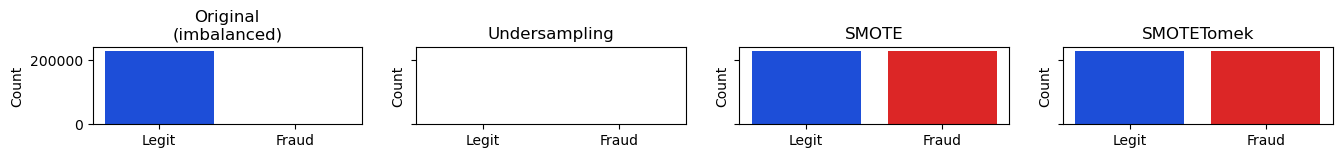

In [21]:
 from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline

# ==============================================================================
# WHY THREE STRATEGIES INSTEAD OF JUST ONE:
# Each strategy makes a different tradeoff between how much data you keep,
# how "real" the data is, and how clean the class boundary ends up.
# Running all three lets us compare their effect on model performance later
# (precision/recall/F1) instead of assuming one method is best by default.
# ==============================================================================

# --- Strategy 1: Random Undersampling ---
# HOW: Randomly deletes majority-class (legit) rows until both classes match
#      the minority class (fraud) count.
# WHY TRY IT: Fastest, simplest, no synthetic/fake data involved.
# TRADEOFF: With ~284k legit vs ~492 fraud, this throws away almost all of
#           the legit transaction data. Expect the smallest, most extreme
#           dataset here (~394 samples per class) - and likely the model that
#           generalizes worst, since it barely sees what "normal" looks like.

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
print(f' After undersampling: {y_rus.value_counts().to_dict()}')
# Both classes (legit and fraud) are now ~ 394 samples - tiny dataset

# --- Strategy 2: SMOTE (Synthetic Minority Oversampling) ---
# HOW: Keeps all legit data, and generates new SYNTHETIC fraud examples by
#      interpolating between real fraud points and their nearest fraud neighbors.
# WHY TRY IT: No data thrown away, model sees far more fraud variety to learn
#             patterns from. Generally the go-to for severe imbalance like this.
# TRADEOFF: Synthetic points can land in unrealistic areas of feature space,
#           especially where real fraud cases are sparse or scattered

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train,y_train)
print(f' After SMOTE : {y_smote.value_counts().to_dict() }')
#Both classes ~227k samples

# --- Strategy 3: SMOTETomek (Combined: SMOTE + Tomek link cleanup) ---
# HOW: First applies SMOTE like above, then removes "Tomek links" - pairs of
#      opposite-class points that are each other's nearest neighbor, meaning
#      they sit right on the boundary and overlap. This trims the ambiguous
#      points sitting between the two classes (usually removing the majority-
#      class member of each pair).
# WHY TRY IT: Combines SMOTE's "don't lose data" benefit with a cleaner,
#             less-overlapping decision boundary - often the best boundary
#             quality of the three.
# TRADEOFF: Most complex, slowest to run of the three strategies.

smt = SMOTETomek(random_state=42)
X_smt,y_smt = smote.fit_resample(X_train,y_train)
print(f'After SMOTETomek : {y_smt.value_counts().to_dict() }')
# Both Classes ~227k samples

# ==============================================================================
# VISUALIZE CLASS COUNTS AFTER EACH STRATEGY
# Side-by-side bar charts let us see the resulting class balance at a glance,
# and later - after training a model on each - we can compare which
# resampling method actually produces the best fraud-detection performance.
# ==============================================================================

strategies = {
    'Original\n(imbalanced)' : y_train,
    'Undersampling' : y_rus,
    'SMOTE': y_smote,
    'SMOTETomek' : y_smt }
fig, axes = plt.subplots(1 ,4, figsize = (16, 1), sharey = True)
for ax, (name, y_s) in zip(axes, strategies.items()):
    counts = y_s.value_counts()
    ax.bar(['Legit', 'Fraud'], [counts[0],counts[1]], 
            color = ['#1d4ed8', '#dc2626'])
    ax.set_title(name)
    ax.set_ylabel('Count')
    plt.savefig('figures/resampling_comparison.png', dpi = 150, bbox_inches='tight')

In [22]:
#=============================
#MODEL TRAINING AND EVALUATION
#=============================
#Train three models on each resampling strategy. The goal is a comparison matrix that shows
#which combination of model + resampling strategy best catches fraud while maintaining false positives.
# ==============================================================================
# STEP 1: DEFINE THE EVALUATION FUNCTION FIRST — BEFORE TRAINING ANYTHING
# WHY: every model we train needs to be scored the same way. Instead of
# repeating the same metric code after each model, we write it ONCE here
# and call this function every time.
# ==============================================================================


from sklearn.metrics import(classification_report, confusion_matrix,
roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, f1_score)

def evaluate_model(model, X_test, y_test, model_name) :
    # Get hard 0/1 predictions from the trained model
    y_pred = model.predict(X_test)
    # Get the predicted PROBABILITY of fraud for each row (not just 0/1)
    # predict_proba returns [prob of 0, prob of 1] per row — [:, 1] keeps only
    # the "probability of fraud" column
    y_prob = model.predict_proba(X_test)[:, 1] #fraud probability

    print(f'\n=== {model_name} ===')
    # Auto-computes precision, recall, F1 for both classes at once
    print(classification_report(y_test,y_pred,target_names=['Legitimate','Fraud']))

    # Key Metrics
    roc_auc = roc_auc_score(y_test, y_prob) #overall ranking quality
    avg_prec = average_precision_score(y_test, y_prob) #Area under PR curve
    f1 = f1_score(y_test, y_pred) #precision/recall balance

    print(f'ROC-AUC: {roc_auc:.4f}')
    print(f'Avg Precision (PR-AUC): {avg_prec:.4f}')
    print(f'F1 (fraud class): {f1:.4f}')

    #Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f'True Negatives: {cm[0,0]} | False Positives: {cm[0,1]}')
    print(f'False Negatives: {cm[1,0]} | True Positives: {cm[1,1]}')

    return {'model': model_name, 'roc_auc': roc_auc,
    'avg_precision': avg_prec, 'f1': f1,
    'fn': cm[1,0], 'fp': cm[0,1]}

 # ==============================================================================
# STEP 2: LOGISTIC REGRESSION — BASELINE + VARIANTS
# WHY MULTIPLE VERSIONS: same model type, different imbalance-handling
# strategies, so any performance difference comes from the data/settings —
# not from switching models.
# ==============================================================================

from sklearn.linear_model import LogisticRegression

#Train on orginal imbalanced data first - baseline
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train,y_train)
results_lr_base = evaluate_model(lr_base, X_test, y_test, 'LR - No Resampling')

#Train on SMOTE data
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_smote,y_smote)
results_lr_smote = evaluate_model(lr_smote, X_test, y_test,'LR - SMOTE')

#Train on undersampled data
lr_rus = LogisticRegression(max_iter=1000, random_state=42)
lr_rus.fit(X_rus,y_rus)
results_lr_rus = evaluate_model(lr_rus, X_test, y_test, 'LR - undersampling')

# --- NEW STRATEGY: class_weight='balanced' ---
# Instead of changing the DATA, this tells the model to penalize mistakes
# on the minority class (fraud) more heavily during training — no resampling
# needed, the model compensates automatically based on class frequency.
lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_balanced.fit(X_train,y_train)
results_lr_bal = evaluate_model(lr_balanced, X_test, y_test, 'LR - class_weight balanced')

### Logistic Regression results, resampling comparison
#
# Interesting result: the baseline (no resampling) actually has the best F1 score
# (0.72) of all four LR variants, despite having the lowest recall (64%).
#
# No resampling: 63 fraud cases caught, only 14 false positives. Best balance
# of precision (0.82) and recall.
#
# SMOTE / undersampling / class weight balanced: all pushed recall up to about
# 92% (catching more real fraud), but precision collapsed to 4 to 6%. SMOTE
# alone flags 1,434 legitimate transactions as fraud, about 100x more false
# positives than baseline.
#
# Why this happens: Logistic Regression draws a relatively simple linear
# decision boundary. Rebalancing the training data to 50/50 tells the model
# fraud is far more common than it actually is (about 0.17% in reality), which
# shifts the boundary aggressively toward flagging transactions as fraud. This
# is a known limitation. Resampling can hurt simpler/linear models even though
# it's often recommended by default for imbalanced classification.
#
# Next step: check whether Random Forest handles the SMOTE resampled data
# better than Logistic Regression did, since tree based models build decision
# boundaries differently and may not overcorrect the same way.



=== LR - No Resampling ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.82      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9582
Avg Precision (PR-AUC): 0.7402
F1 (fraud class): 0.7200
True Negatives: 56850 | False Positives: 14
False Negatives: 35 | True Positives: 63

=== LR - SMOTE ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9712
Avg Precision (PR-AUC): 0.7235
F1 (fraud class): 0.1110
True Negatives: 55430 | False Positives: 1434
False Negatives: 8 | Tr


=== RF - smote ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.88      0.82      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9632
Avg Precision (PR-AUC): 0.8680
F1 (fraud class): 0.8466
True Negatives: 56853 | False Positives: 11
False Negatives: 18 | True Positives: 80


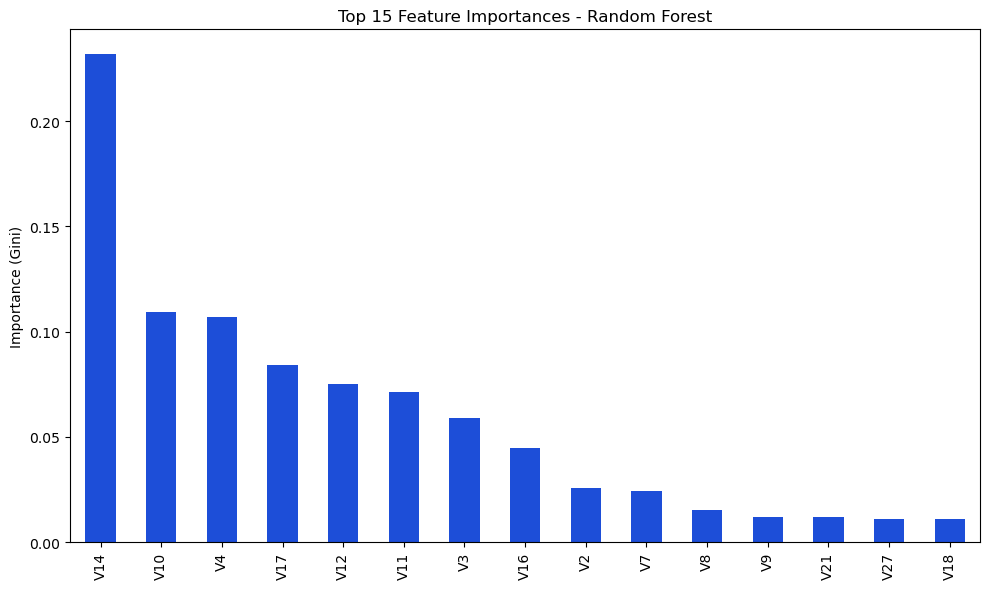

In [27]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier

#Random Forest on SMOTE data, typically gives the strongest combination
rf_smote = RandomForestClassifier(n_estimators=100, max_depth=None, #let trees grow fully
min_samples_split=2, class_weight='balanced',#additional weight boost
random_state=42,n_jobs=-1) #use all cpu scores
rf_smote.fit(X_smote,y_smote)
results_rf_smote = evaluate_model(rf_smote, X_test, y_test, 'RF - smote')

#Feature importance
importances = pd.Series(rf_smote.feature_importances_,index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(15).plot(kind='bar', color ='#1d4ed8')
plt.title('Top 15 Feature Importances - Random Forest')
plt.ylabel('Importance (Gini)')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')

# Random Forest results, SMOTE resampled data
#
# Random Forest on SMOTE resampled data is the best model so far by a wide
# margin, beating every LR variant on every metric.
#
# RF - SMOTE: 80 fraud cases caught (82% recall), only 11 false positives
# (88% precision). F1 of 0.85, compared to 0.72 for the best LR variant
# (no resampling) and 0.11 for LR trained on the same SMOTE data.
#
# Why this differs from Logistic Regression: LR draws one linear decision
# boundary through the whole feature space. Rebalancing the training data
# to 50/50 with SMOTE shifts that single boundary hard, since the model
# is told fraud is far more common than it really is. Random Forest works
# differently. It builds many separate decision trees, each splitting on
# individual feature thresholds (for example, is V17 below some value).
# This lets it carve out flexible, localized regions instead of relying
# on one global boundary, so it does not overcorrect the same way even
# though it was trained on the same artificially balanced data.
#
# Takeaway: resampling strategy and model choice interact. SMOTE hurt a
# linear model here but helped a tree based model. This means resampling
# is not a universal fix, its effect depends on what kind of model is
# being trained on top of it.
           

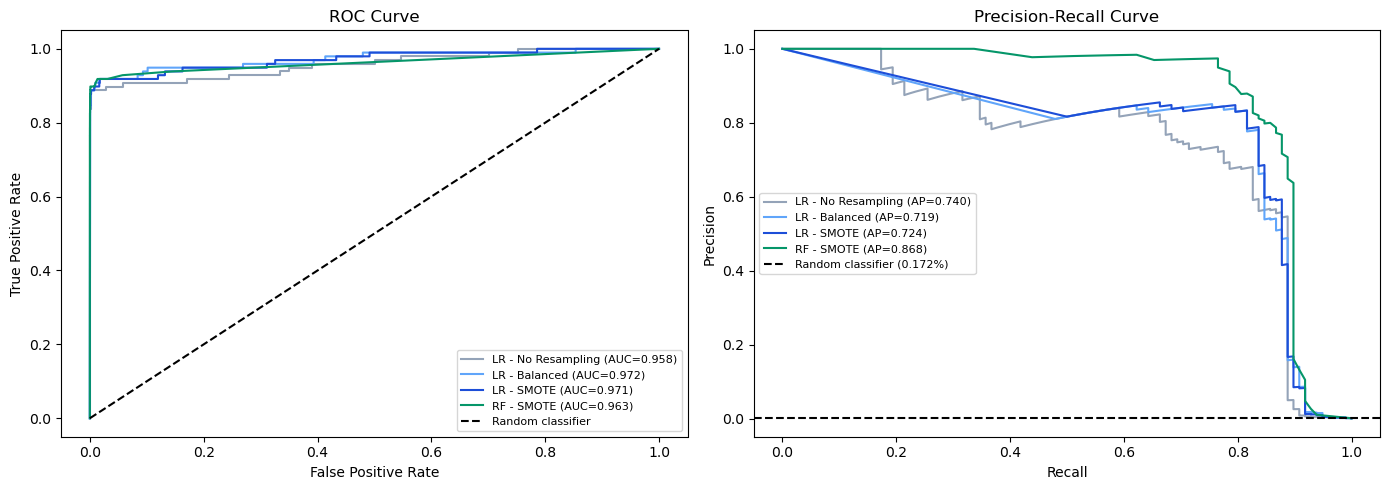

In [26]:
# =============================
# PRECISION-RECALL CURVE, THE KEY VISUALIZATION
# =============================
# PR curve is more informative than ROC curve on imbalanced data.
# ROC can look great even when precision is terrible at high recall.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_to_plot = [
    (lr_base, 'LR - No Resampling', '#94a3b8'),
    (lr_balanced, 'LR - Balanced', '#60a5fa'),
    (lr_smote, 'LR - SMOTE', '#1d4ed8'),
    (rf_smote, 'RF - SMOTE', '#059669'),
]

for model, name, color in models_to_plot:
    y_prob = model.predict_proba(X_test)[:, 1]

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', color=color)

    # Precision-Recall curve
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    avg_prec = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, label=f'{name} (AP={avg_prec:.3f})', color=color)

# ROC plot formatting
axes[0].plot([0,1], [0,1], 'k--', label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=8)

# PR plot formatting
axes[1].axhline(y=0.00172, color='k', linestyle='--',
                 label='Random classifier (0.172%)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/roc_pr_curves.png', dpi=150, bbox_inches='tight')

# ROC and precision-recall curve results
#
# ROC-AUC scores are all close together and look uniformly strong: 0.958 to
# 0.972 across all four models. Based on ROC alone, LR - Balanced looks
# slightly better than RF - SMOTE (0.972 vs 0.963), which is misleading.
#
# The precision-recall curve tells a very different story. RF - SMOTE has
# an average precision of 0.868, clearly ahead of every LR variant, which
# all sit between 0.719 and 0.740. The gap between models is much larger
# and much more informative on the PR curve than on the ROC curve.
#
# This is the ROC vs PR issue in action. ROC's x-axis (false positive rate)
# is measured against a huge number of legitimate transactions, so even
# hundreds of false positives barely move the curve. Precision is measured
# against only the transactions the model actually flagged, a much smaller
# number, so the same false positives have a much bigger visible effect.
# On this dataset, with fraud under 1% of transactions, PR curves are the
# more honest way to compare these models.
#
# Looking at the PR curve directly, the green RF - SMOTE line stays close
# to precision 1.0 for most of the recall range and only drops off sharply
# after around recall 0.6, while the LR variants (gray and blue lines)
# start losing precision much earlier, around recall 0.3 to 0.4. This
# matches the AP scores and confirms RF - SMOTE is the strongest model
# of the four, not just by one summary number but across most thresholds.
#
# Takeaway: always check the PR curve on imbalanced classification
# problems, not just ROC-AUC, since ROC can compress real differences
# between models into what looks like a small gap.


Best F1 threshold: 0.800
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.97      0.77      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962


High-recall threshold (0.060):
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56864
       Fraud       0.13      0.91      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.95      0.61     56962
weighted avg       1.00      0.99      0.99     56962



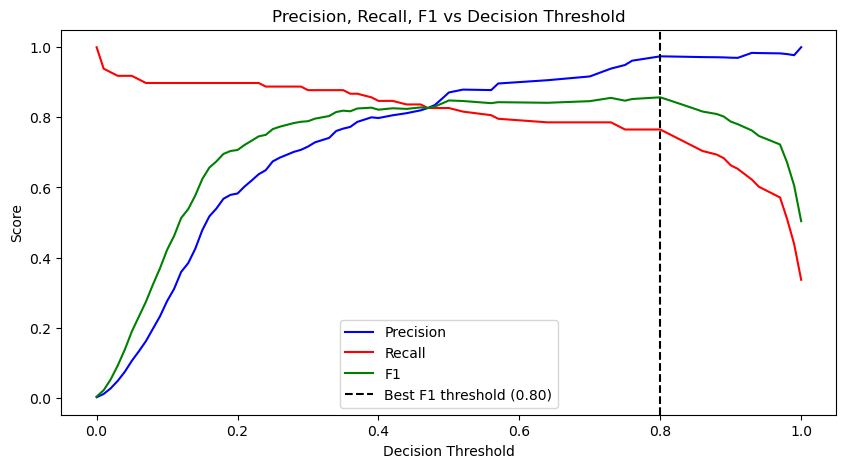

In [25]:
# =============================================================
# PHASE 5, THRESHOLD TUNING (THE BUSINESS DECISION)
# The default threshold for predict() is 0.5, but 0.5 is not chosen based
# on your data or your business costs, it is just an arbitrary default.
# =============================================================

from sklearn.metrics import precision_recall_curve

# Get fraud probabilities from the best model (Random Forest on SMOTE)
y_prob_rf = rf_smote.predict_proba(X_test)[:, 1]

# Compute precision and recall at every possible threshold
# precision_recall_curve automatically tests many threshold cutoffs and
# returns the precision/recall pair at each one
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)

# Compute F1 score at each threshold
# F1 combines precision and recall into one number, so we can find the
# single threshold that balances both best
# 1e-8 is added to the denominator to avoid dividing by zero
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# Find the threshold that gives the highest F1 score
# precisions/recalls have one extra final value compared to thresholds,
# so [:-1] drops that last value to keep the arrays the same length
# np.argmax finds the index of the highest F1 score in the array
best_threshold_f1 = thresholds[np.argmax(f1_scores[:-1])]
print(f'Best F1 threshold: {best_threshold_f1:.3f}')

# Plot precision, recall, and F1 against every threshold
# This lets you visually see the tradeoff instead of just one number
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], 'b-', label='Precision')
plt.plot(thresholds, recalls[:-1], 'r-', label='Recall')
plt.plot(thresholds, f1_scores[:-1], 'g-', label='F1')
# Draw a vertical line marking the best F1 threshold found above
plt.axvline(best_threshold_f1, color='black', linestyle='--',
            label=f'Best F1 threshold ({best_threshold_f1:.2f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Decision Threshold')
plt.legend()
plt.savefig('figures/threshold_analysis.png', dpi=150, bbox_inches='tight')

# Apply the custom threshold instead of the default 0.5
# Any probability at or above best_threshold_f1 gets classified as fraud (1)
# .astype(int) converts the True/False results into 1/0
y_pred_tuned = (y_prob_rf >= best_threshold_f1).astype(int)
print(classification_report(y_test, y_pred_tuned,
      target_names=['Legitimate', 'Fraud']))

# BUSINESS SCENARIO: prioritize recall (catch more fraud, accept more
# false positives)
# In real fraud detection, missing fraud is often more costly than a
# false alarm, so a business might intentionally choose a lower threshold
# than the "optimal" F1 threshold above

# Find the threshold where recall is at least 0.90
# np.where(recalls[:-1] >= 0.90) finds all indices where recall meets
# this requirement, [0] gets the array of matching indices, [-1] takes
# the LAST one, which corresponds to the strictest (highest) threshold
# that still achieves at least 90% recall
high_recall_thresh = thresholds[np.where(recalls[:-1] >= 0.90)[0][-1]]
y_pred_high_recall = (y_prob_rf >= high_recall_thresh).astype(int)
print(f'\nHigh-recall threshold ({high_recall_thresh:.3f}):')
print(classification_report(y_test, y_pred_high_recall,
      target_names=['Legitimate', 'Fraud']))

# Threshold tuning results
#
# Best F1 threshold (0.80): precision 0.97, recall 0.77, F1 0.86.
# Catches 75 of 98 fraud cases, with very few false positives.
#
# High-recall threshold (0.06): precision 0.13, recall 0.91, F1 0.23.
# Catches 89 of 98 fraud cases, but precision drops sharply. At this
# threshold only about 13 out of every 100 flagged transactions are
# actually fraud, meaning roughly 600 legitimate transactions get
# flagged as false alarms to catch 14 more real fraud cases.
#
# This shows the real tradeoff behind threshold choice. Moving the
# threshold from 0.80 to 0.06 increases recall by 14 percentage points,
# but costs a large increase in false positives. Neither threshold is
# objectively correct on its own, the right choice depends on the
# actual cost of a missed fraud case versus the cost of a false alarm
# to a legitimate customer.
#
# In a real business setting, this decision would be made using a cost
# matrix. If a missed fraud case costs the company far more than the
# cost of a false block (for example, chargebacks and lost trust from
# fraud are expensive, while a false block is just a temporary
# inconvenience), a lower threshold like 0.06 might be justified despite
# the low precision. If customer experience and avoiding false blocks
# is the higher priority, the 0.80 threshold is the better choice.
# Threshold selection is a business decision, not just a modeling one.
